In [2]:
# 1. Upgrade Plotly directly inside your Colab server container engine
!pip install plotly --upgrade

# 2. Baseline framework imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 3. Read the Nobel asset table
df_data = pd.read_csv('data/nobel_prize_data.csv')
print("Initial Dataset Dimensions:", df_data.shape) # Yields (962, 16)
df_data.head(2)

Initial Dataset Dimensions: (962, 16)


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA


In [3]:
# 1. Convert object string timestamps to pandas Datetime indices
df_data.birth_date = pd.to_datetime(df_data.birth_date)

# 2. Split fraction strings on the forward slash to compute percentages
separated_values = df_data.prize_share.str.split('/', expand=True)
numerator = pd.to_numeric(separated_values[0])
denominator = pd.to_numeric(separated_values[1])
df_data['share_pct'] = numerator / denominator

print("Data type casting complete. Numeric Share sample:")
print(df_data[['full_name', 'share_pct']].head())

Data type casting complete. Numeric Share sample:
                      full_name  share_pct
0  Jacobus Henricus van 't Hoff        1.0
1               Sully Prudhomme        1.0
2        Emil Adolf von Behring        1.0
3                Frédéric Passy        0.5
4             Jean Henry Dunant        0.5


In [4]:
# --- Repeat Winners Investigation ---
is_winner = df_data.duplicated(subset=['full_name'], keep=False)
multiple_winners = df_data[is_winner]
print(f"Laureates awarded a prize more than once: {multiple_winners.full_name.nunique()}")

# --- Categorical Breakdown Split Bar Chart ---
cat_men_women = df_data.groupby(['category', 'sex'], as_index=False).agg({'prize': pd.Series.count})
cat_men_women.sort_values('prize', ascending=False, inplace=True)

v_bar_split = px.bar(
    cat_men_women,
    x='category',
    y='prize',
    color='sex',
    title='Nobel Prizes Awarded per Category Split by Gender'
)
v_bar_split.update_layout(xaxis_title='Nobel Prize Category', yaxis_title='Number of Prizes')
v_bar_split.show()

Laureates awarded a prize more than once: 6


In [10]:
# Aggregate total prizes won based on the current current names of birth countries
df_countries = df_data.groupby(['birth_country_current', 'ISO'], as_index=False).agg({'prize': pd.Series.count})

world_map = px.choropleth(
    df_countries,
    locations='ISO',
    color='prize',
    hover_name='birth_country_current',
    # Change "Matter" with a capital M to "matter" in lowercase:
color_continuous_scale=px.colors.sequential.matter,
    title='Global Distribution of Nobel Laureates by Birth Country'
)
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

In [11]:
# 1. Group institutional affiliations cleanly
country_city_org = df_data.groupby(by=['organization_country', 'organization_city', 'organization_name'], as_index=False).agg({'prize': pd.Series.count})
country_city_org = country_city_org.sort_values('prize', ascending=False)

# 2. Build the nested sunburst path map
burst = px.sunburst(
    country_city_org,
    path=['organization_country', 'organization_city', 'organization_name'],
    values='prize',
    title='Regional Breakdown of Scientific Discoveries & Research Centers'
)
burst.update_layout(coloraxis_showscale=False)
burst.show()

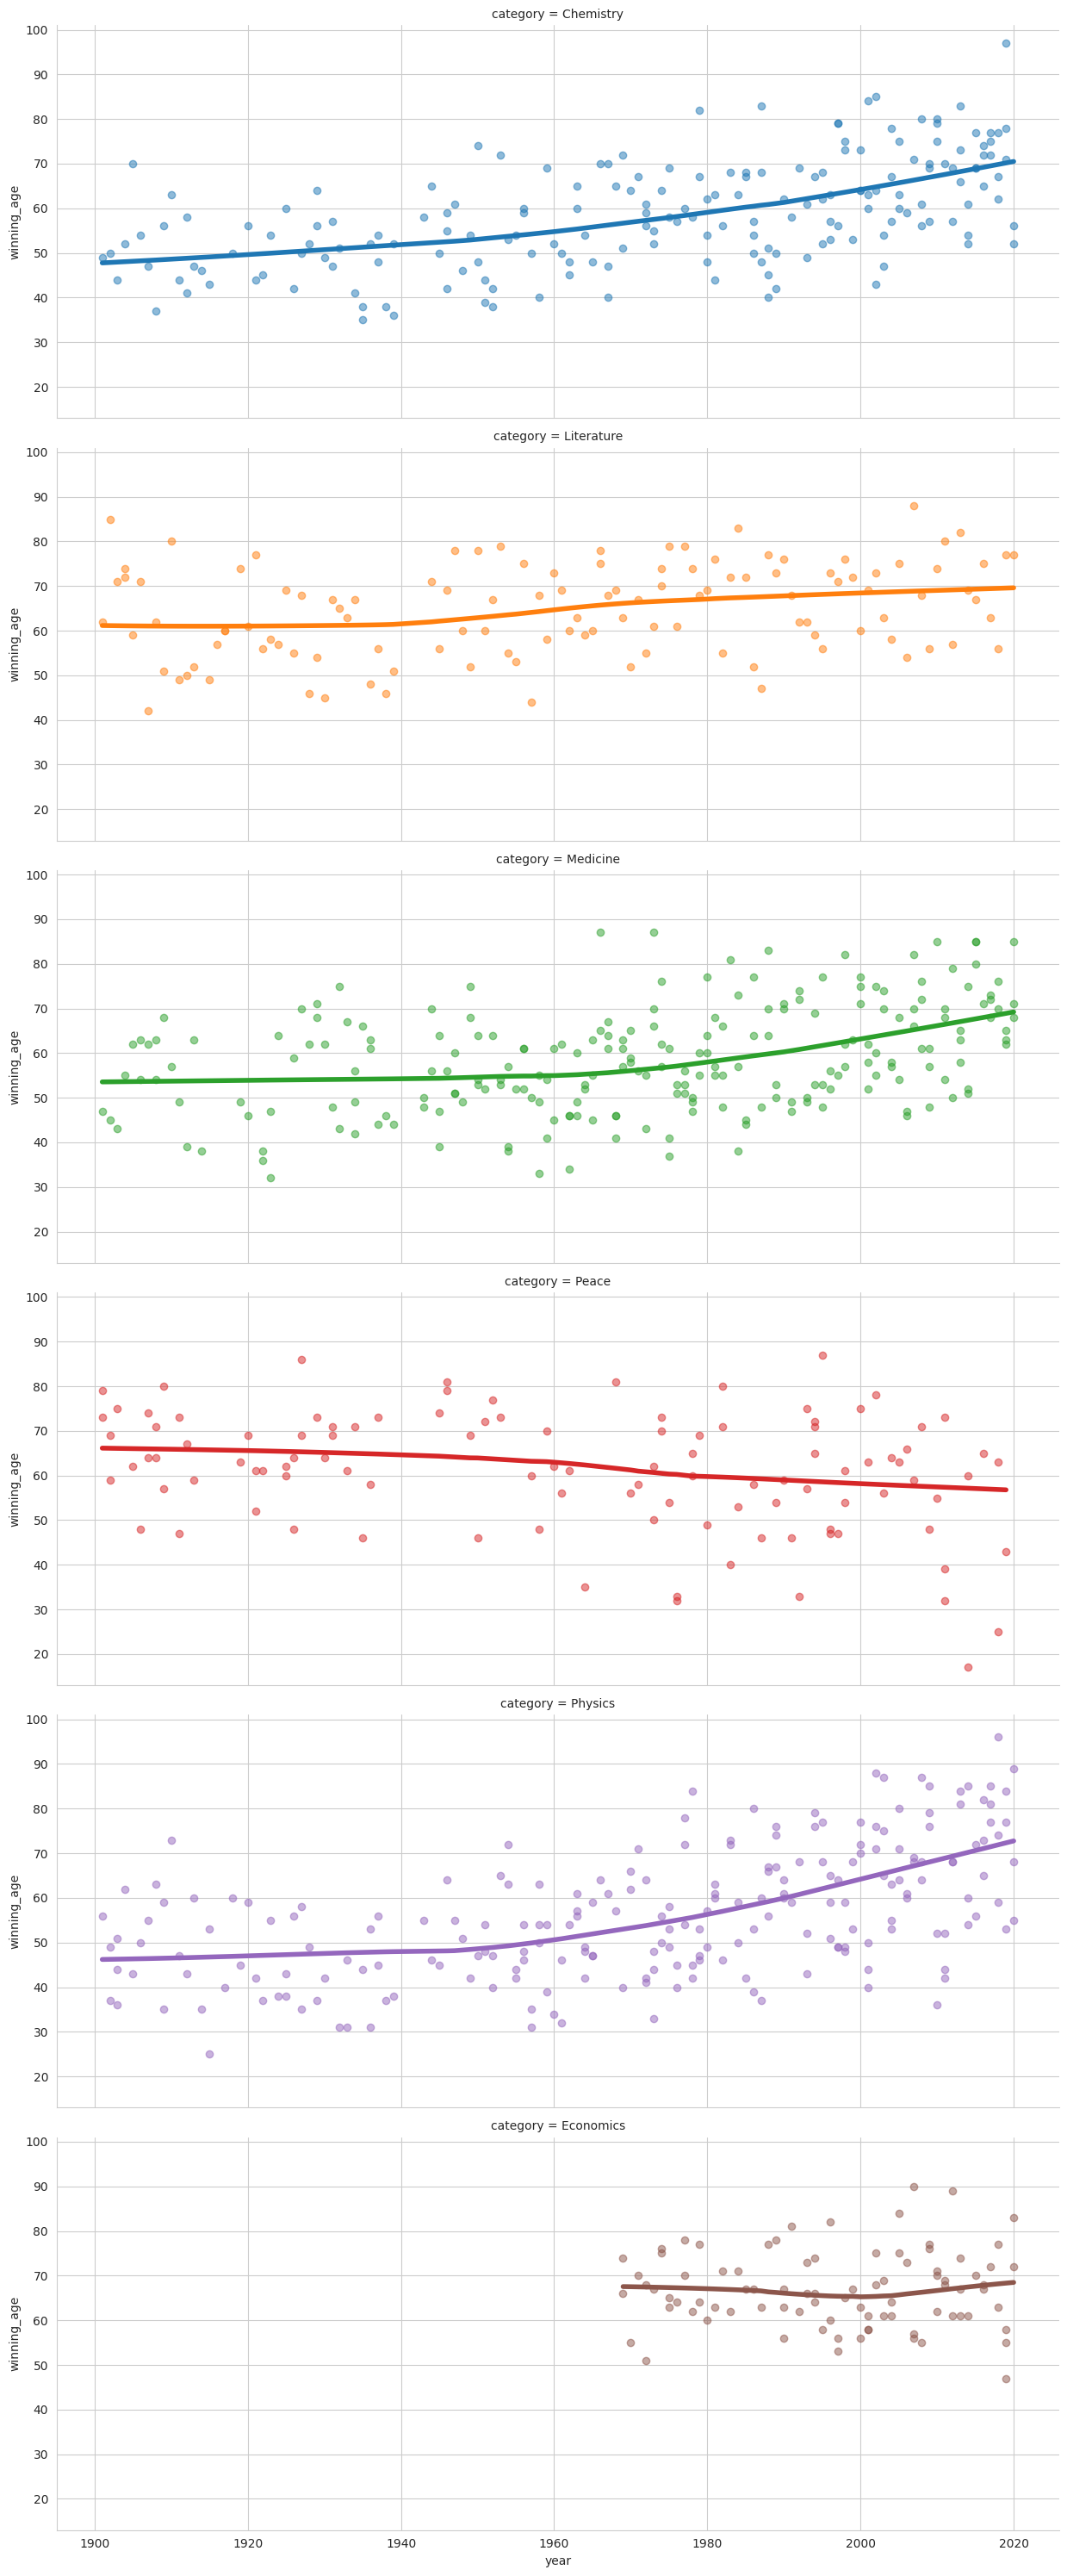

In [12]:
# 1. Calculate age at ceremony
df_data['winning_age'] = df_data.year - df_data.birth_date.dt.year

# 2. Render multi-row categorical line trends
with sns.axes_style('whitegrid'):
    g = sns.lmplot(
        data=df_data,
        x='year',
        y='winning_age',
        row='category',
        hue='category',
        lowess=True,
        aspect=2.5,
        scatter_kws={'alpha': 0.5},
        line_kws={'linewidth': 4}
    )
plt.show()

In [13]:
# 1. Group the dataset to count prizes by country, city, and institution
country_city_org = df_data.groupby(
    by=['organization_country', 'organization_city', 'organization_name'],
    as_index=False
).agg({'prize': pd.Series.count})

country_city_org = country_city_org.sort_values('prize', ascending=False)

# 2. Build the nested sunburst path map
burst = px.sunburst(
    country_city_org,
    path=['organization_country', 'organization_city', 'organization_name'],
    values='prize',
    title='Where do Discoveries Take Place? (Regional Concentration Map)'
)

burst.update_layout(
    xaxis_title='Number of Prizes',
    yaxis_title='City',
    coloraxis_showscale=False
)

burst.show()